In [26]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import io
from google.colab import files


Please upload an image file.


Saving cock.jpg to cock.jpg
Successfully uploaded and loaded: cock.jpg


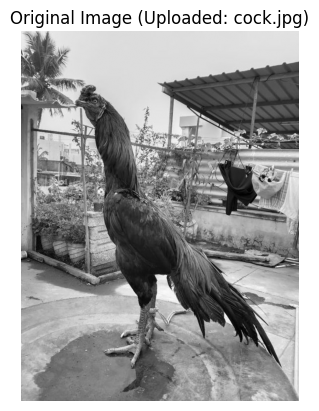

In [27]:


print("Please upload an image file.")
uploaded = files.upload()

image = None
filename = ""

for fname, data in uploaded.items():
    filename = fname
    # Read image from bytes and decode as grayscale
    image_array = np.frombuffer(data, np.uint8)
    image = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)
    print(f"Successfully uploaded and loaded: {filename}")
    break # Process only the first uploaded image

if image is not None:
    plt.imshow(image, cmap='gray')
    plt.title(f"Original Image (Uploaded: {filename})")
    plt.axis('off')
else:
    print("No image uploaded or unable to decode image. Please ensure you upload a valid image file.")

(np.float64(-0.5), np.float64(563.5), np.float64(751.5), np.float64(-0.5))

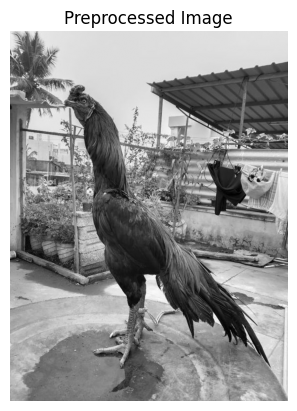

In [30]:
# Normalisasi (0–255) dan tipe data
preprocessed_image = cv2.normalize(
    image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX
).astype(np.uint8)

plt.imshow(preprocessed_image, cmap='gray')
plt.title("Preprocessed Image")
plt.axis('off')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

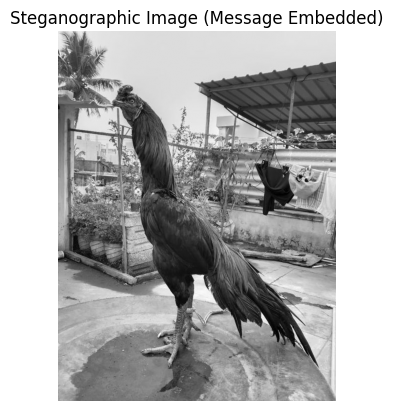

In [31]:
def embed_message(image, message):
    binary_message = ''.join(format(ord(c), '08b') for c in message)
    binary_message += '1111111111111110'

    flat_image = image.flatten().copy()

    if len(binary_message) > len(flat_image):
        raise ValueError("Pesan terlalu panjang untuk citra ini")

    for i in range(len(binary_message)):
        pixel = flat_image[i]
        pixel = pixel & 254
        pixel = pixel | int(binary_message[i])
        flat_image[i] = np.uint8(pixel)

    return flat_image.reshape(image.shape)

secret_message = 'PIKIRKAN SECARA LOGIKA'
stego_image = embed_message(preprocessed_image, secret_message)

# tampilkan
plt.imshow(stego_image, cmap='gray')
plt.title("Steganographic Image (Message Embedded)")
plt.axis('off')

# simpan di VM Colab
output_path = "stego_image.png"
cv2.imwrite(output_path, stego_image)

# otomatis download ke komputer
files.download(output_path)

Upload gambar steganografi (PNG/BMP)


Saving stego_image.png to stego_image (4).png
Pesan tersembunyi: PIKIRKAN SECARA LOGIKA


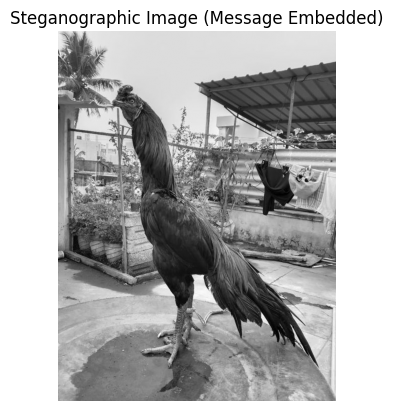

In [33]:


def extract_message_from_upload():
    delimiter = '1111111111111110'

    print("Upload gambar steganografi (PNG/BMP)")
    uploaded = files.upload()
    image_path = list(uploaded.keys())[0]

    stego_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    flat_image = stego_image.flatten()
    binary_data = ""

    for pixel in flat_image:
        binary_data += str(pixel & 1)
        if binary_data.endswith(delimiter):
            break

    binary_data = binary_data[:-len(delimiter)]

    message = ""
    for i in range(0, len(binary_data), 8):
        message += chr(int(binary_data[i:i+8], 2))

    return message

# tampilkan
plt.imshow(stego_image, cmap='gray')
plt.title("Steganographic Image (Message Embedded)")
plt.axis('off')

# JALANKAN
print("Pesan tersembunyi:", extract_message_from_upload())
